# Phase 1 optimizer -- real-course validation against actual race results

This notebook is one of 7 split from `phase1_optimizer.ipynb` (kept alongside these as a single-file reference/narrative version).
Equation/section citations here follow `docs/tt pacing optimizer.md`, the
project's canonical numbering, written as "(design-doc Eq. N)" /
"(design-doc Section N.M)"; display-unit conventions (km/min/km-h⁻¹) are
implemented in `phase_1_0_common.py`'s `as_km`/`as_min`/`as_kmh` helpers, shared
by all 7 notebooks. This one covers
**a ballpark sanity check of the optimizer's finish times against the real race results the commit cites**.

It is fully self-contained: every rider/course/baseline it needs is
rebuilt here via `phase_1_0_common.py` (shared by all 7 split notebooks),
so it runs standalone from a fresh kernel without any other notebook
having run first. Courses used: Giro10, TdF16, TARA (real) -- no synthetic courses. Approx. runtime: ~4-6 min.

Builds its own Giro10/TdF16/TARA solves directly (rather than reusing
another notebook's leftover state, which the single-notebook version
used to do implicitly) -- same rider/mesh/`smoothing_length_m`
combination `tests/test_phase_1_*_gpx.py` uses for each.

In [1]:
import sys
sys.path.insert(0, ".")
import phase_1_0_common as pc

pc.print_rider_summary()

reference_rider        mass= 72.0 kg  CP= 280.0 W  W'= 20.0 kJ  CdA=0.25 m^2  P_max=   900 W
evenepoel_like_rider   mass= 63.5 kg  CP= 425.0 W  W'= 20.0 kJ  CdA=0.21 m^2  P_max=  1400 W
ganna_like_rider       mass= 82.0 kg  CP= 480.0 W  W'= 20.0 kJ  CdA=0.19 m^2  P_max=  1600 W


## Real-course validation

All three GPX courses from the commit, each with the rider/mesh
parameters `tests/test_phase_1_*_gpx.py` uses, compared against the
actual race result the commit cites:

- **TARA (Tour Auvergne-Rhone-Alpes) 2026 Stage 3** -- 28.4 km TTT, won by
  Team Visma \| Lease a Bike in 32:52.17 (1972.17 s). This notebook (like
  the test) simulates a **solo** rider against a **team** result, so the
  comparison band is loose (`reference_rider`, 80 intervals,
  `smoothing_length_m=200`).
- **TdF 2026 Stage 16** -- the mountainous course (`evenepoel_like_rider`,
  60 intervals, `smoothing_length_m=300`). Won by Remco Evenepoel in
  32:19 (1939 s).
- **Giro 2026 Stage 10** -- the flat course (`ganna_like_rider`, 80
  intervals, `smoothing_length_m=300`). Won by Filippo Ganna in 45:53
  (2753 s).

In [2]:
giro10_data = pc.load_gpx(pc.GPX_DIR / "giro2026_stage10.gpx")
giro10_course = pc.CourseProcessor().process(
    giro10_data, n_nodes=len(giro10_data.s_m), smoothing_length_m=300.0
)
opt_giro10 = pc.ITTOptimizer(
    pc.ganna_like_rider, giro10_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)
res_giro10_baseline = opt_giro10.optimize(n_intervals=80)

tdf16_data = pc.load_gpx(pc.GPX_DIR / "tdf2026_stage16.gpx")
tdf16_course = pc.CourseProcessor().process(
    tdf16_data, n_nodes=min(len(tdf16_data.s_m), 800), smoothing_length_m=300.0
)
opt_tdf16 = pc.ITTOptimizer(
    pc.evenepoel_like_rider, tdf16_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)
res_tdf16_baseline = opt_tdf16.optimize(n_intervals=60)

tara_data = pc.load_gpx(pc.GPX_DIR / "tara2026_stage3.gpx")
tara_course = pc.CourseProcessor().process(
    tara_data, n_nodes=len(tara_data.s_m), smoothing_length_m=200.0
)
opt_tara = pc.ITTOptimizer(
    pc.reference_rider, tara_course, pc.calm_wind, scheme="hermite_simpson", solver="slsqp"
)
res_tara = opt_tara.optimize(n_intervals=80)

real_courses = [
    ("TARA 2026 Stage 3 (TTT)", tara_course, res_tara, 1972.17, (1.0, 1.5)),
    ("TdF 2026 Stage 16 (ITT)", tdf16_course, res_tdf16_baseline, 1939.0, (0.82, 1.18)),
    ("Giro 2026 Stage 10 (ITT)", giro10_course, res_giro10_baseline, 2753.0, (0.85, 1.15)),
]

for label, _course, res, real_time_s, (lo, hi) in real_courses:
    ratio = res.time_total_s / real_time_s
    in_band = lo < ratio < hi
    print(
        f"{label:28s} T_nlp={pc.as_min(res.time_total_s):6.2f} min   real={pc.as_min(real_time_s):6.2f} min   "
        f"ratio={ratio:.3f}  band=({lo}, {hi})  in_band={in_band}"
    )

TARA 2026 Stage 3 (TTT)      T_nlp= 45.93 min   real= 32.87 min   ratio=1.397  band=(1.0, 1.5)  in_band=True
TdF 2026 Stage 16 (ITT)      T_nlp= 37.34 min   real= 32.32 min   ratio=1.155  band=(0.82, 1.18)  in_band=True
Giro 2026 Stage 10 (ITT)     T_nlp= 42.70 min   real= 45.88 min   ratio=0.931  band=(0.85, 1.15)  in_band=True


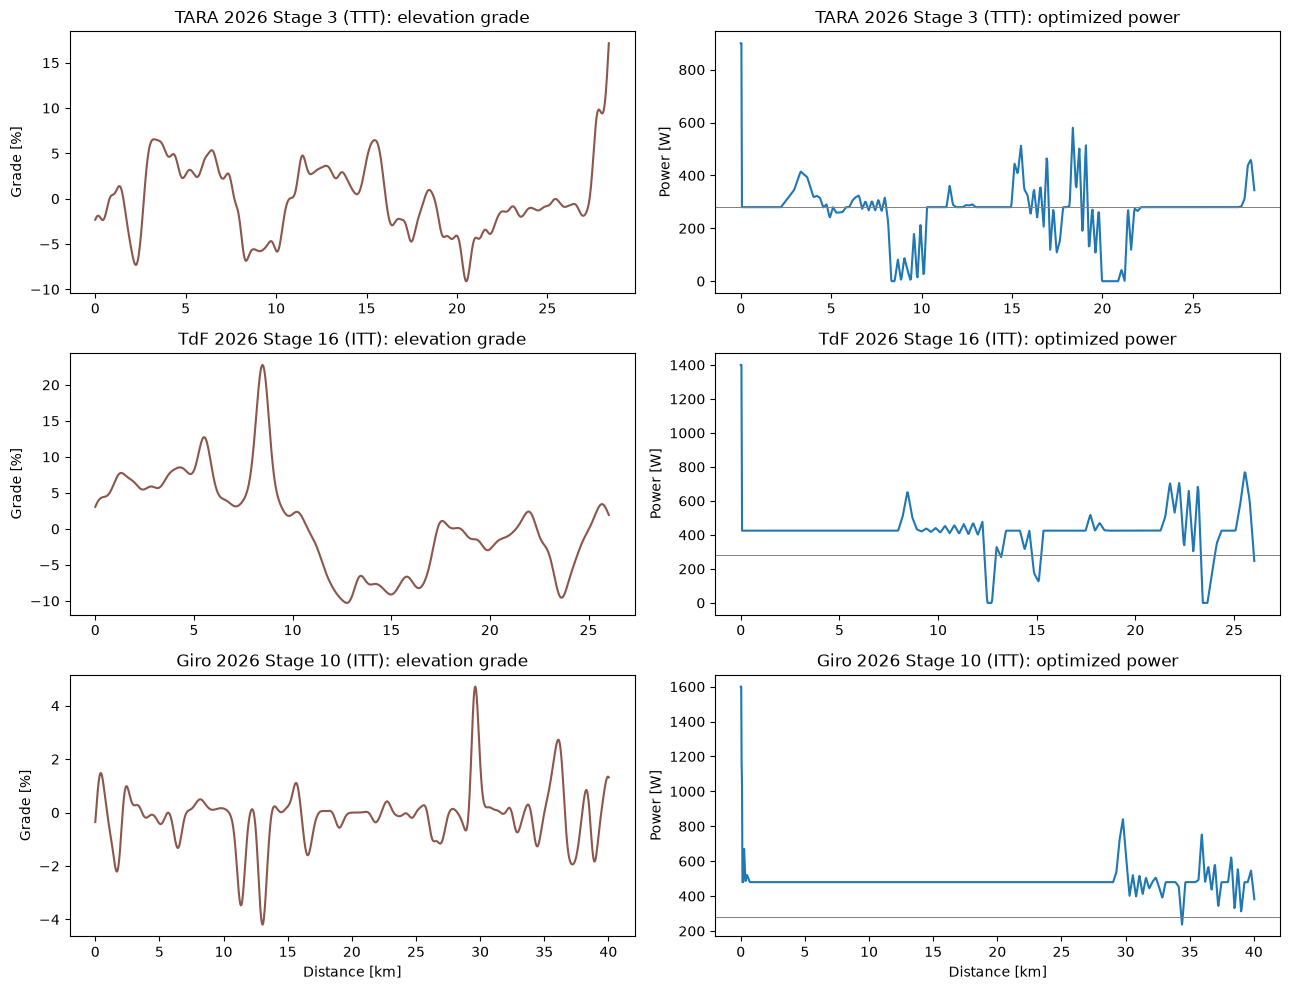

In [3]:
fig, axes = pc.plt.subplots(3, 2, figsize=(13, 10))
for row, (label, course, res, _real_time_s, _band) in enumerate(real_courses):
    grade_pct = pc.np.tan(course.theta_rad) * 100.0
    axes[row, 0].plot(pc.as_km(course.s_m), grade_pct, color="tab:brown")
    axes[row, 0].set_ylabel("Grade [%]")
    axes[row, 0].set_title(f"{label}: elevation grade")

    axes[row, 1].plot(pc.as_km(res.full_course_s_m), res.full_course_power_W, color="tab:blue")
    axes[row, 1].axhline(pc.reference_rider.cp_W, color="gray", linewidth=0.7)
    axes[row, 1].set_ylabel("Power [W]")
    axes[row, 1].set_title(f"{label}: optimized power")

axes[-1, 0].set_xlabel("Distance [km]")
axes[-1, 1].set_xlabel("Distance [km]")
fig.tight_layout()
pc.plt.show()